In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("netflix_titles.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully!
Rows: 8807
Columns: 12


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (8807, 12)

Column Names:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,8807,8807,s8807,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,8807,2,Movie,6131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,8807,8807,Zubaan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,6173,4528,Rajiv Chilaka,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,7982,7692,David Attenborough,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,7976,748,United States,2818,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,8797,1767,"January 1, 2020",109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,8807.0,NaN,NaN,NaN,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0
rating,8803,17,TV-MA,3207,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,8804,220,1 Season,1793,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values[missing_values > 0])

Missing Values:
director      2634
cast           825
country        831
date_added      10
rating           4
duration         3
dtype: int64


In [6]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [7]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (8807, 12)


In [8]:
columns_to_fill = [
    "director",
    "cast",
    "country",
    "rating"
]

for column in columns_to_fill:
    df[column] = df[column].fillna("Unknown")

print("Missing values handled successfully!")

Missing values handled successfully!


In [9]:
type_counts = df["type"].value_counts()

print(type_counts)

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


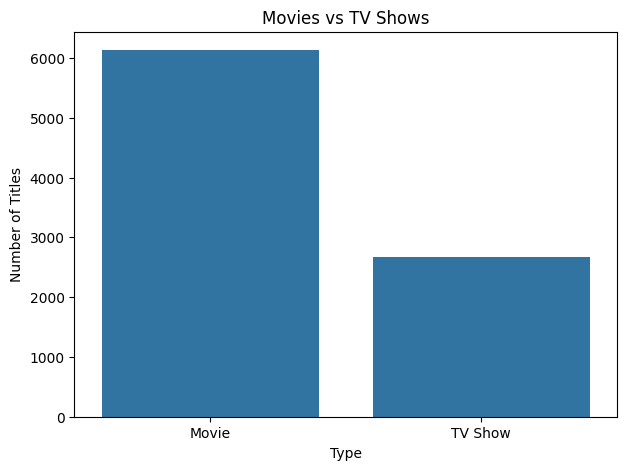

In [10]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="type")

plt.title("Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Number of Titles")

plt.show()

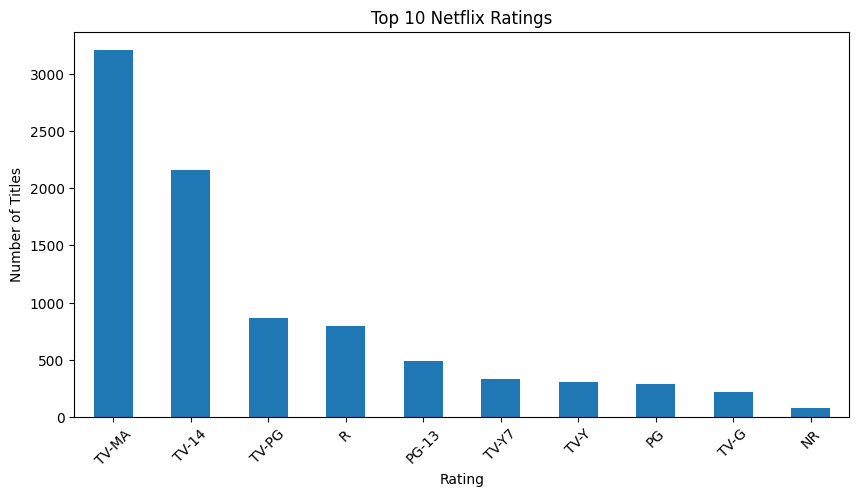

In [11]:
rating_counts = df["rating"].value_counts().head(10)

plt.figure(figsize=(10,5))

rating_counts.plot(kind="bar")

plt.title("Top 10 Netflix Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()

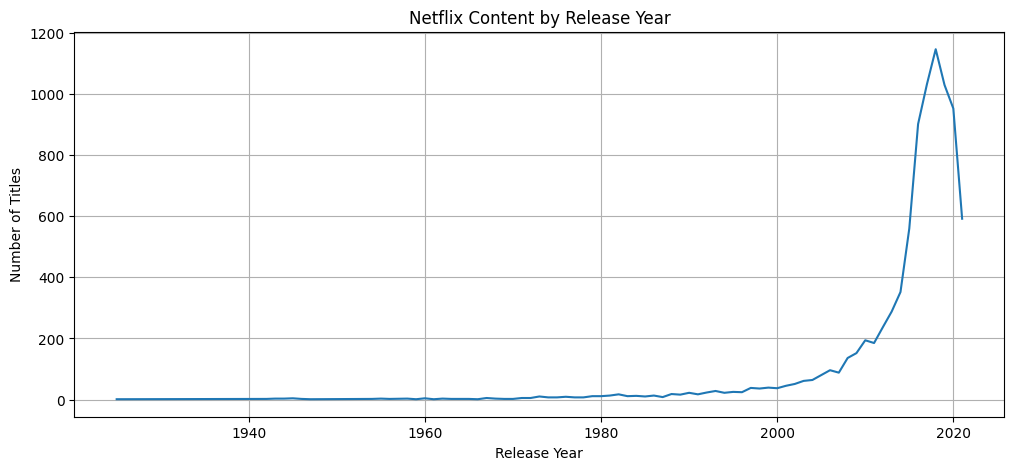

In [12]:
year_counts = df["release_year"].value_counts().sort_index()

plt.figure(figsize=(12,5))

year_counts.plot(kind="line")

plt.title("Netflix Content by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.grid()

plt.show()

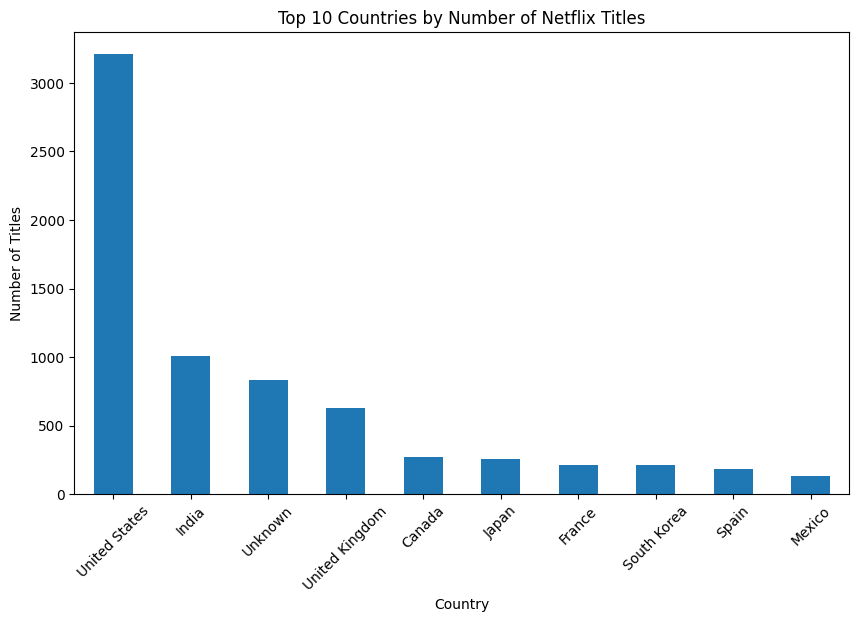

In [13]:
df["main_country"] = df["country"].apply(
    lambda x: x.split(",")[0].strip()
)

top_countries = df["main_country"].value_counts().head(10)

plt.figure(figsize=(10,6))

top_countries.plot(kind="bar")

plt.title("Top 10 Countries by Number of Netflix Titles")
plt.xlabel("Country")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()

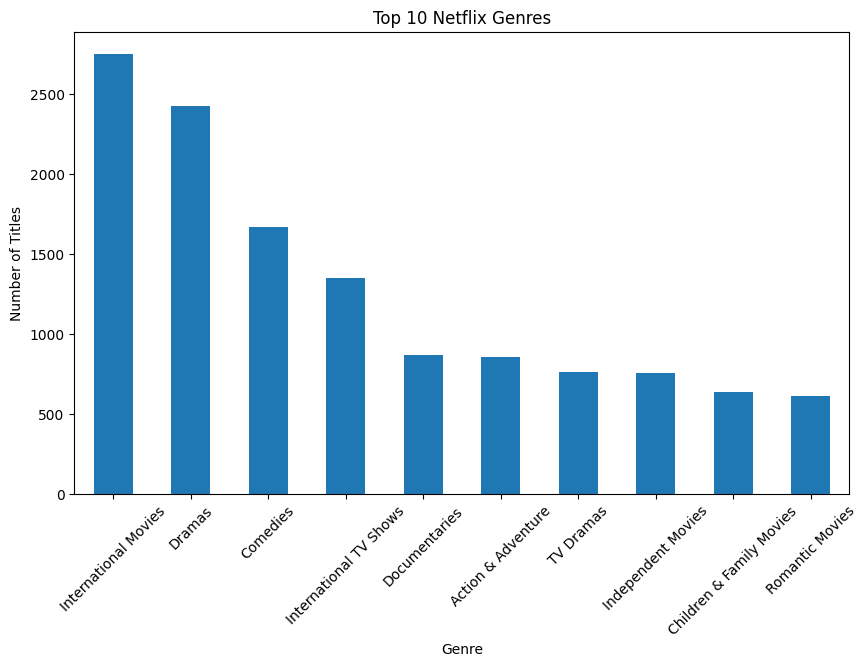

In [14]:
genres = df["listed_in"].str.split(", ").explode()

top_genres = genres.value_counts().head(10)

plt.figure(figsize=(10,6))

top_genres.plot(kind="bar")

plt.title("Top 10 Netflix Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()

In [15]:
type_percentage = df["type"].value_counts(normalize=True) * 100

print(type_percentage.round(2))

type
Movie      69.62
TV Show    30.38
Name: proportion, dtype: float64


## Key Insights

1. The dataset contains both Movies and TV Shows.
2. Movies and TV Shows have different proportions in the dataset.
3. Some ratings are much more common than others.
4. Netflix content comes from many different countries.
5. Some genres occur more frequently than others.
6. The number of titles varies significantly across release years.
7. Missing values were identified and handled during the data-cleaning process.